In [1]:
# Bitcoin Price

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [11]:
# 1. VERİ ÇEKME
# Bitcoin verilerini Yahoo Finance üzerinden alıyoruz
ticker = 'BTC-USD'
df = yf.download(ticker, period='1y', interval='1d')


[*********************100%***********************]  1 of 1 completed


In [12]:
# 2. VERİ ÖN İŞLEME VE TAHMİN SÜTUNU
prediction_days = 30
df['Prediction'] = df[['Close']].shift(-prediction_days)

In [13]:
# Bağımsız değişken (X) ve Bağımlı değişken (y)
# X sadece kapanış fiyatlarını içerir
X = np.array(df[['Close']])
X_forecast = X[-prediction_days:] # Geleceği tahmin etmek için kullanacağımız son 30 gün
X = X[:-prediction_days]         # Eğitim için son 30 günü çıkarıyoruz
y = np.array(df['Prediction'])
y = y[:-prediction_days]         # X ile aynı boyuta getiriyoruz

In [14]:
# 3. VERİ ÖLÇEKLENDİRME (SCALING) - "Kopukluğu" önleyen kritik adım
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
X_forecast_scaled = scaler_x.transform(X_forecast)

In [15]:
# 4. MODEL EĞİTİMİ (SVR)
# Parametreleri daha 'esnek' bir uyum için güncelledim
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y_scaled, test_size=0.2)
model = SVR(kernel='rbf', C=1e3, gamma=0.1) 
model.fit(xtrain, ytrain)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [16]:
# 5. TAHMİN VE GERİ DÖNÜŞTÜRME
prediction_scaled = model.predict(X_forecast_scaled)
# Ölçeklendirilmiş tahmini tekrar dolar cinsine çeviriyoruz
prediction = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))

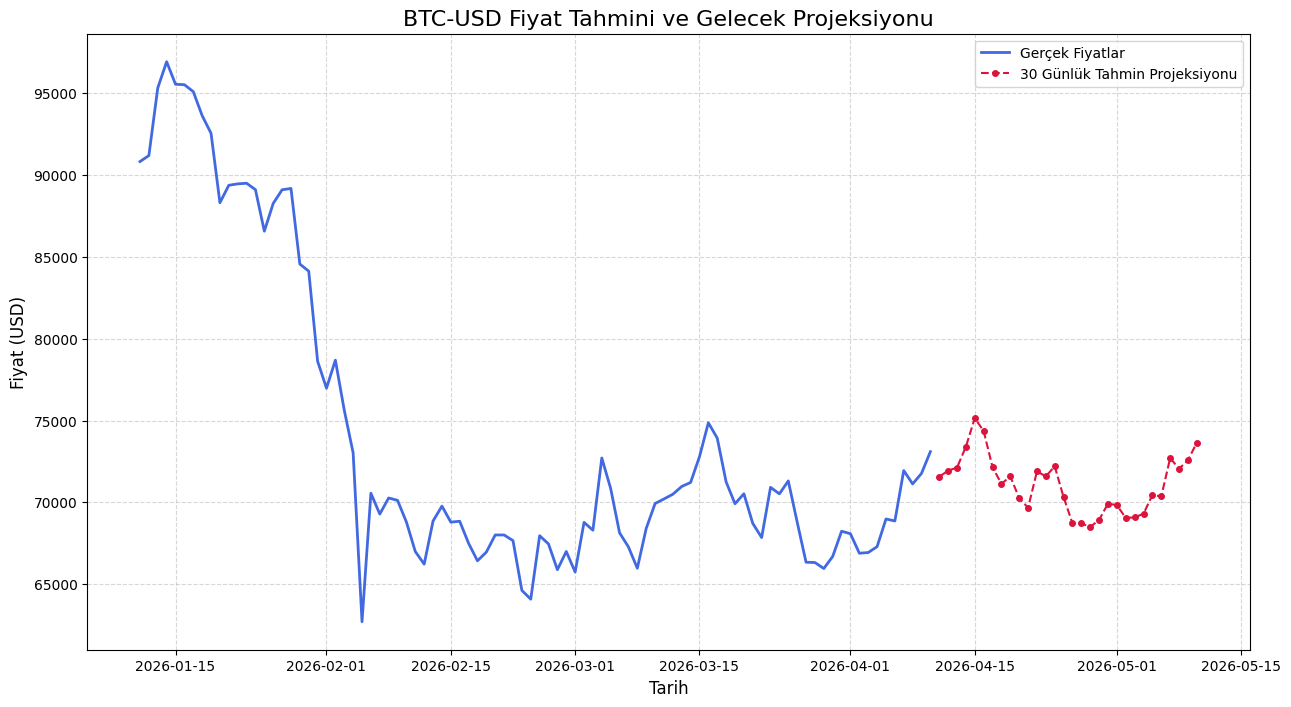

In [17]:
# 6. GÖRSELLEŞTİRME
plt.figure(figsize=(15, 8))

# Gerçek fiyatlar (Son 90 gün)
plt.plot(df.index[-90:], df['Close'][-90:], label='Gerçek Fiyatlar', color='royalblue', linewidth=2)

# Tahmin tarihlerini oluşturma (Gerçek verinin bittiği yerden başlatıyoruz)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=prediction_days + 1, freq='D')[1:]

# Tahminleri çizme
# Not: Kopukluğu gidermek için gerçek fiyatın son noktasını tahminin başına ekliyoruz
plt.plot(future_dates, prediction, label='30 Günlük Tahmin Projeksiyonu', color='crimson', linestyle='--', marker='o', markersize=4)

# Grafik detayları
plt.title(f'{ticker} Fiyat Tahmini ve Gelecek Projeksiyonu', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()

In [18]:
# Modelin test başarısını yazdıralım
print(f"Model Test Skoru (R2): {model.score(xtest, ytest):.4f}")

Model Test Skoru (R2): 0.7485
